In [1]:
import yfinance as yf

# load data
t = yf.download(
    "AAPL",
    start = "1960-01-01",  
    end = "2025-08-31", 
    auto_adjust = True
    )

# restructure data
t = t.droplevel(level='Ticker', axis=1)

# rename columns
t.rename(
    columns = {
        'Open':'o', 
        'High':'h', 
        'Low':'l', 
        'Close':'c', 
        'Volume':'v'
    }, 
    inplace = True)

#next close
t.loc[:,'nc'] = t.c.shift(-1)

# future price change
t.loc[:, 'fpc'] = 100.0 * (t.nc/t.c - 1)

[*********************100%***********************]  1 of 1 completed


In [2]:
import pandas_ta as ta

# Momentum
t['f0'] = ta.rsi(t.c, length=14)
st = ta.stoch(t.h, t.l, t.c)
t['f1'] = st.STOCHk_14_3_3
t['f2'] = st.STOCHd_14_3_3
t['f3'] = ta.roc(t.c, length=10)

# Trend
t['f4'] = ta.ema(t.c, length=10)
t['f5'] = ta.ema(t.c, length=50)
macd = ta.macd(t.c)
t['f6'] = macd.MACD_12_26_9
t['f7'] = macd.MACDs_12_26_9
t['f8'] = ta.adx(t.h, t.l, t.c).ADX_14

# Volatility
t['f9'] = ta.atr(t.h, t.l, t.c, length=14)
bb = ta.bbands(t.c, length=20, std=2)
t['f10'] = bb['BBP_20_2.0']
t['f11'] = bb['BBB_20_2.0']

# Volume / Flow
t['f12'] = ta.obv(t.c, t.v) / 1e9
t['f13'] = ta.mfi(
    t.h, t.l, t.c, t.v, length=14)
t['f14'] = ta.vwap(t.h, t.l, t.c, t.v)

/var/folders/s1/fwkx4m816qb85j8vnrlygx7m0000gq/T/ipykernel_42641/2395132769.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7.67419519e+06 6.70952922e+06 4.71300795e+06 ... 7.05061754e+09
 1.24222942e+10 2.69456518e+09]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  t['f13'] = ta.mfi(
/var/folders/s1/fwkx4m816qb85j8vnrlygx7m0000gq/T/ipykernel_42641/2395132769.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.64433935e+07 9.16007214e+06 8.29768152e+06 ... 9.09911106e+09
 9.61151526e+09 6.89181138e+09]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  t['f13'] = ta.mfi(


In [3]:
feats = [f'f{i}' for i in range(15)]

# leave only features and price changes
t = t[feats + ['fpc']].dropna()

# delete rows where price change is zero
t = t[t.fpc != 0.0]

# define targets and weights
t.loc[:,'y'] = 1 / t.fpc
t.loc[:,'w'] = t.fpc ** 2

n = len(t) // 2

# split data chronologically
t1 = t.head(n - 30)
t2 = t.tail(n - 30)

# features
X1 = t1[feats].values
X2 = t2[feats].values

# targets
y1 = t1.y.values
y2 = t2.y.values

# weights
w1 = t1.w.values
w2 = t2.w.values

# price changes
c1 = t1.fpc.values
c2 = t2.fpc.values

In [4]:
from sklearn import ensemble as ens

# specify the model
m = ens.GradientBoostingRegressor(
    loss = "squared_error",
    learning_rate = 0.0075,
    n_estimators = 50,
    max_depth = 1,
    min_samples_leaf = 250,
    min_samples_split = 500,
    subsample = 0.5,
    max_features = 0.4,
    random_state = 42,
    n_iter_no_change = None,
)


# fit / train the model
m.fit(X1, y1, sample_weight = w1)

# predict in- and out-of-samples
p1 = m.predict(X1)
p2 = m.predict(X2)

# calculate profits as
# price changes multiplied by positions
pr1 = c1 * p1
pr2 = c2 * p2

In [5]:
import numpy as np

# Sharpe ratio
def get_sharpe(x):
    m = np.mean(x)
    s = np.std(x)
    r = m / s
    k = np.sqrt(252)
    return k * m / s

# Sharpe ratios in- and out-of-sample
s1 = get_sharpe(pr1)
s2 = get_sharpe(pr2)

# Share ratios of constant model
s1_ref = get_sharpe(c1)
s2_ref = get_sharpe(c2)

print('In-sample:')
print('Constant Model:', round(s1_ref,2))
print('Our Model:', round(s1,2), '\n')

print('Out-of-sample:')
print('Constant Model:', round(s2_ref,2))
print('Our Model:', round(s2,2))

In-sample:
Constant Model: 0.4
Our Model: 0.76 

Out-of-sample:
Constant Model: 1.08
Our Model: 1.32


In [6]:
from numpy.random import permutation as prm

ref_sharpe = get_sharpe(c2 * p2)

n_tries = 100_000

fake_sharpes = np.array([
    get_sharpe(c2 * prm(p2))
    for _ in range(n_tries)
])

n = (fake_sharpes > ref_sharpe).sum()
print(f'\n{n} times out of {n_tries}\n')

perc = 100.0 * n / n_tries
print(perc, '%')


1 times out of 100000

0.001 %


In [7]:
slpg = 0.02

pr2_slpg = c2 * p2 

pr2_slpg -= slpg * np.abs(
    np.diff(p2, prepend=0)
    )

srp_slpg = get_sharpe(pr2_slpg)

print('\nSharpe Ratio with Slippage:')
print(round(srp_slpg,2))


Sharpe Ratio with Slippage:
1.31


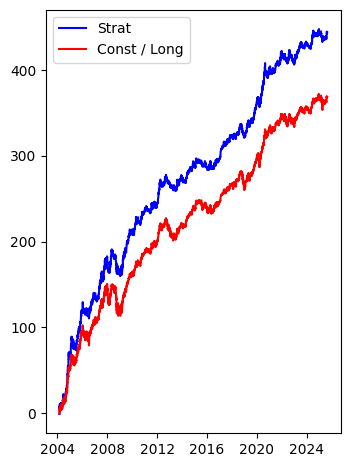

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize = (3.8 ,5.5))
plt.plot(t2.index,
    np.cumsum(pr2_slpg)/np.std(pr2_slpg), 
    color = 'b', label = 'Strat')
plt.plot(t2.index,np.cumsum(c2)/np.std(c2), 
    color = 'r', label = 'Const / Long')
plt.legend(); plt.show()